Necessary Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Loading the dataset

In [2]:
df = pd.read_csv("D:/Coding/Exploratory_Data_Analysis/data/Provided/Clean/cleaned_data.csv")
df.head()

,name,price,mileage,engine_cc,fuel,kilometer_run,is_automatic,is_4WD,age
0,Hyundai | i20 Active S | TDi | 2015 | Hatchbac...,2475000.0,14.0,1400.0,1,42000.0,0,0,10
1,Excellent car on sale (Hyundai),750000.0,11.0,1399.0,1,87412.0,1,0,20
2,TATA 407 Container (Tata),700000.0,12.0,2956.0,2,60000.0,0,0,12
3,4x4 swaraj Mazda (Mahindra),600000.0,14.0,1200.0,2,33516.0,0,1,8
4,i20 Active good for used few time (Hyundai),375.0,17.0,1200.0,1,2400.0,1,0,6


In [3]:
plt.style.use('seaborn-v0_8-darkgrid')

**Basic Distribution Plots**

Histograms

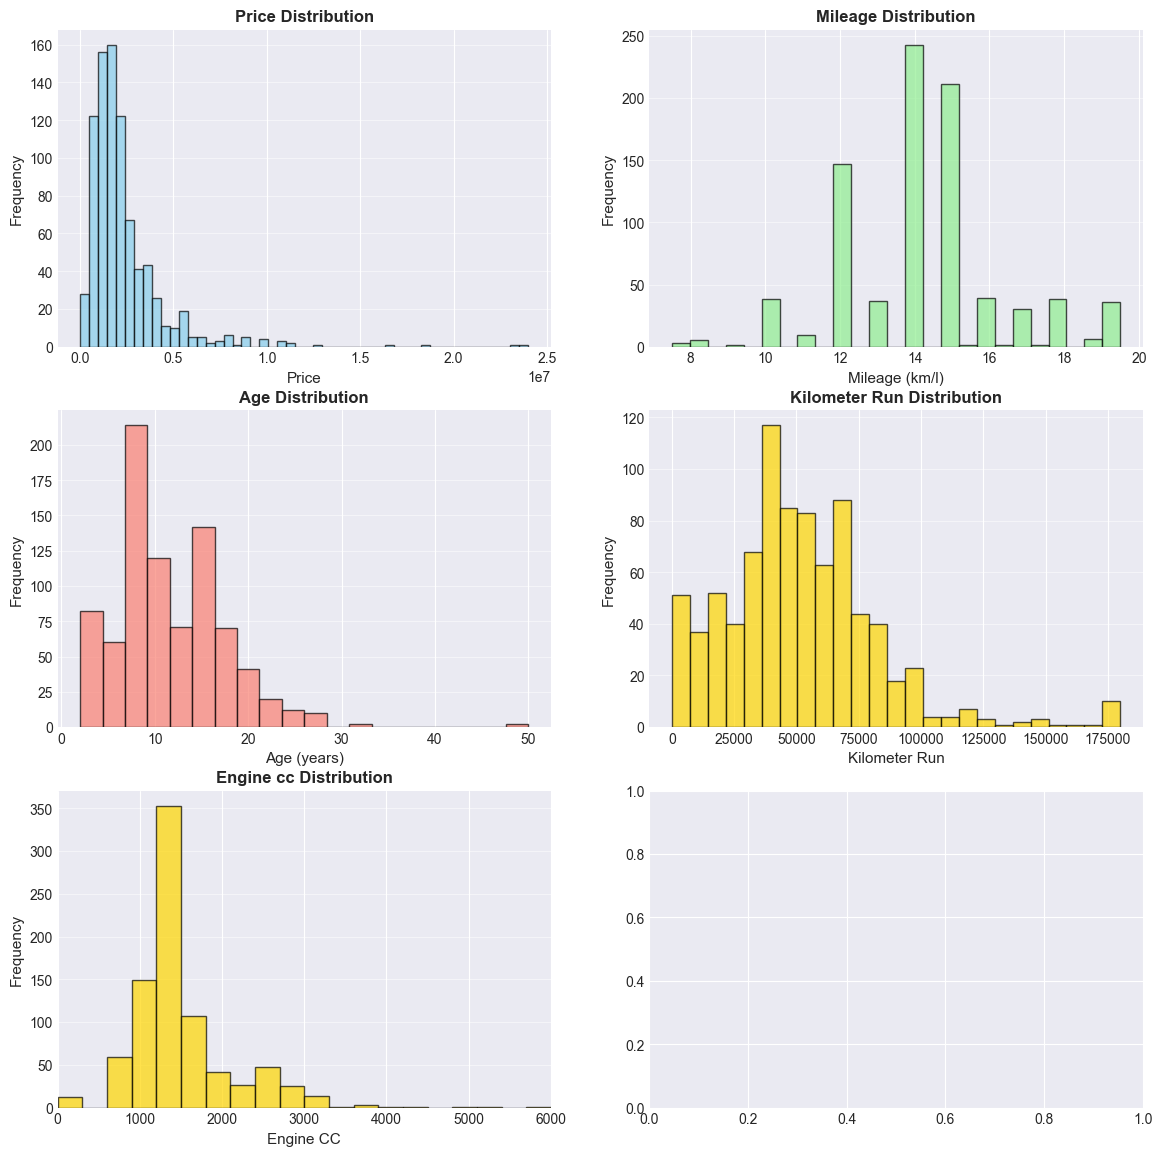

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# Price
axes[0, 0].hist(df['price'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Price', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.5)
# axes[0, 0].set_xlim((0.0, 8000000))

# Mileage
axes[0, 1].hist(df['mileage'], bins=25, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Mileage (km/l)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Mileage Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.5)

# Age
axes[1, 0].hist(df['age'], bins=20, color='salmon', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Age (years)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Age Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.5)

# Kilometer Run
axes[1, 1].hist(df['kilometer_run'], bins=25, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Kilometer Run', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Kilometer Run Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.5)

# Engine Power
axes[2, 0].hist(df['engine_cc'], bins=50, color='gold', edgecolor='black', alpha=0.7)
axes[2, 0].set_xlabel('Engine CC', fontsize=11)
axes[2, 0].set_ylabel('Frequency', fontsize=11)
axes[2, 0].set_title('Engine cc Distribution', fontsize=12, fontweight='bold')
axes[2, 0].grid(axis='y', alpha=0.5)
axes[2, 0].set_xlim((0.0, 6000))


plt.show()

**Insights:**
- Price distribution is right-skewed, indicating most cars are in the lower price range with a few expensive outliers.
- Mileage distribution shows most cars have moderate fuel efficiency, with some high-mileage outliers.
- Age distribution suggests the majority of cars are relatively new, with fewer older vehicles.
- Kilometer run is concentrated at lower values, indicating most cars have not been driven extensively.
- Engine CC distribution shows most cars have moderate engine capacity, with some high-performance outliers.

Pie charts for Fuel Type, Manual/Automatic and Drive

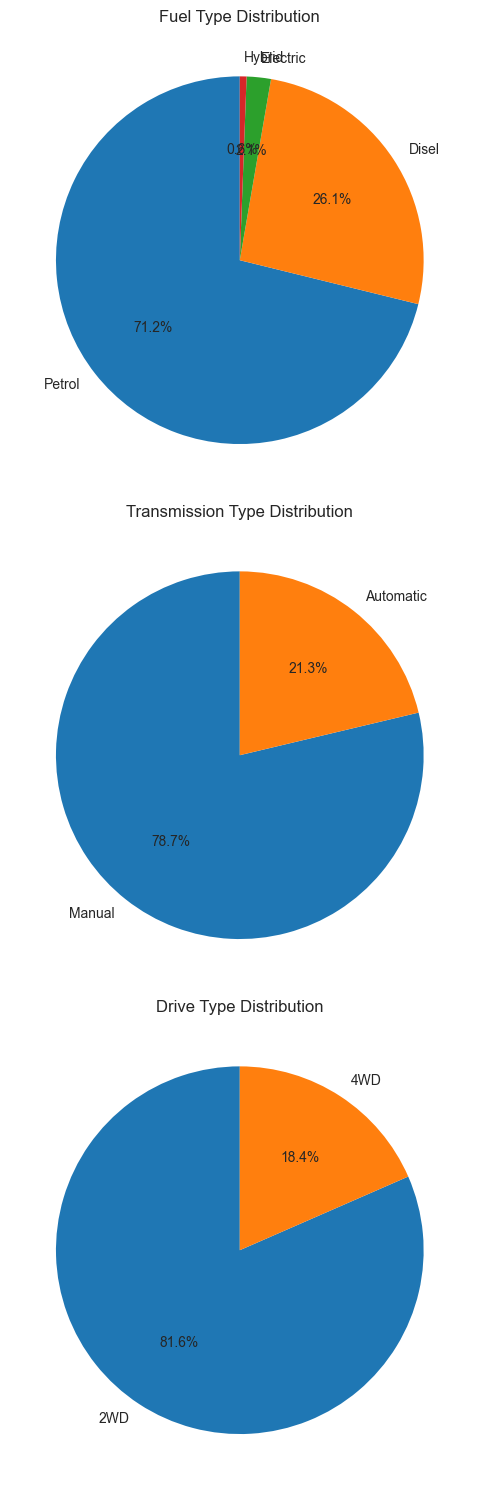

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15))  

# Fuel Pie Chart
fuel_counts = df['fuel'].value_counts()  
axes[0].pie(fuel_counts, labels=['Petrol','Disel','Electric','Hybrid'], autopct='%1.1f%%', startangle=90)
axes[0].set_title("Fuel Type Distribution")

# Transmission Type Pie Chart
auto_counts = df['is_automatic'].value_counts()
axes[1].pie(auto_counts, labels=['Manual','Automatic'], autopct='%1.1f%%', startangle=90)
axes[1].set_title("Transmission Type Distribution")

# Drive Type Pie Chart
drive_counts = df['is_4WD'].value_counts()
axes[2].pie(drive_counts, labels=['2WD','4WD'], autopct='%1.1f%%', startangle=90)
axes[2].set_title("Drive Type Distribution")

plt.tight_layout()
plt.show()

**Insights:**
- Petrol is the most common fuel type, followed by Diesel, with Electric and Hybrid being less common.
- Manual transmission dominates over automatic, indicating a preference for manual cars.
- 2WD vehicles are more prevalent than 4WD, suggesting most cars are standard drive rather than off-road capable.

Box Plots for relations building by grouping

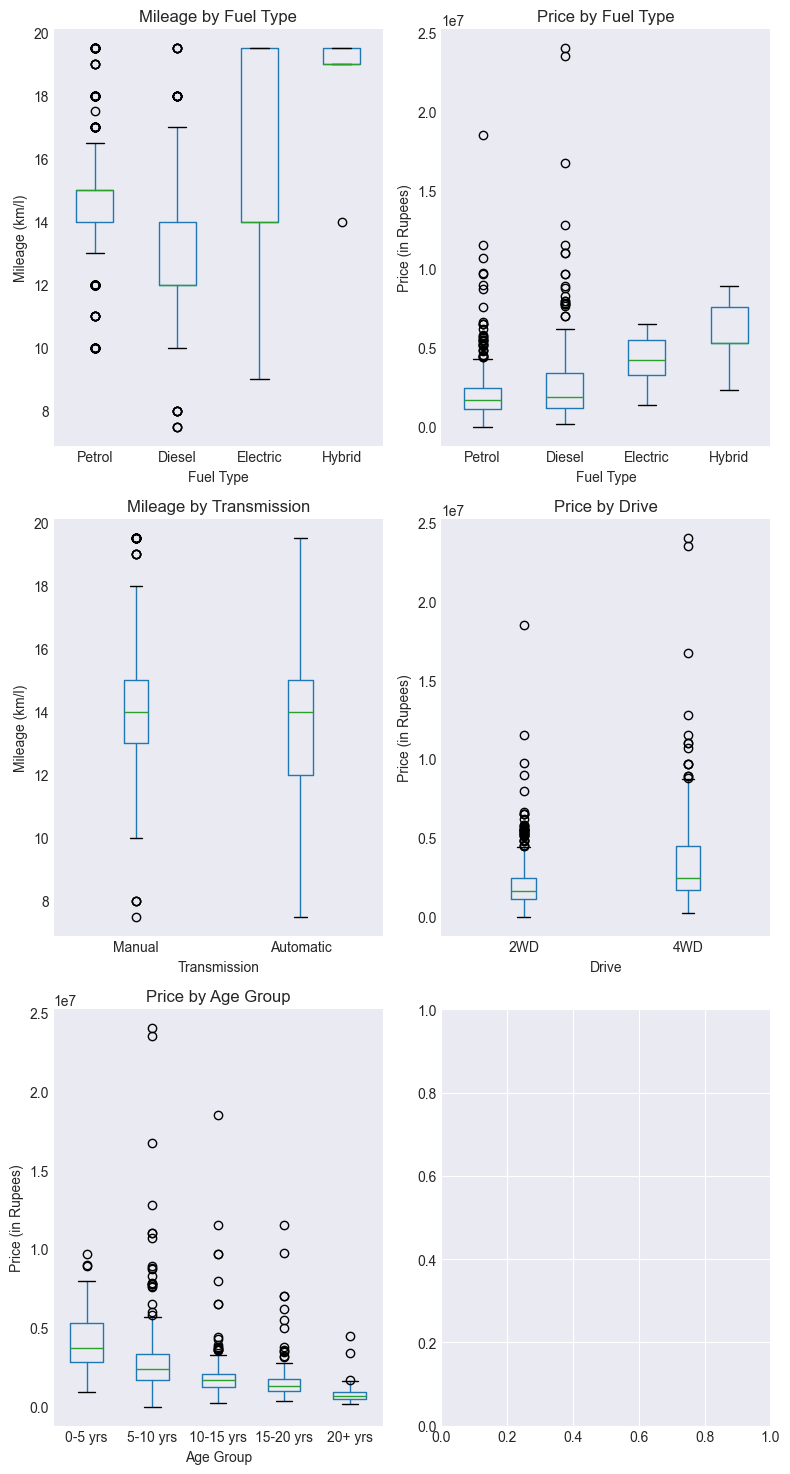

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

def create_boxplots(df):
    fig, axes = plt.subplots(3, 2, figsize=(8, 15))

    def plot_box(ax, column, by, title, xticks, xticklabels, ylabel, xlabel):
        df.boxplot(column=column, by=by, grid=False, ax=ax)
        ax.set_title(title)
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(xlabel)

    plot_box(axes[0][0], 'mileage', 'fuel',
             "Mileage by Fuel Type",
             [1,2,3,4], ['Petrol','Diesel','Electric','Hybrid'],
             "Mileage (km/l)", "Fuel Type")

    plot_box(axes[0][1], 'price', 'fuel',
             "Price by Fuel Type",
             [1,2,3,4], ['Petrol','Diesel','Electric','Hybrid'],
             "Price (in Rupees)", "Fuel Type")

    plot_box(axes[1][0], 'mileage', 'is_automatic',
             "Mileage by Transmission",
             [1,2], ['Manual','Automatic'],
             "Mileage (km/l)", "Transmission")

    plot_box(axes[1][1], 'price', 'is_4WD',
             "Price by Drive",
             [1,2], ['2WD','4WD'],
             "Price (in Rupees)", "Drive")


    bins = [0, 5, 10, 15, 20, 30]
    labels = ['0-5 yrs', '5-10 yrs', '10-15 yrs', '15-20 yrs', '20+ yrs']
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

    plot_box(axes[2][0], 'price', 'age_group',
             "Price by Age Group",
             [1,2,3,4,5], labels,
             "Price (in Rupees)", "Age Group")

    df.drop('age_group', axis=1, inplace=True)

    plt.suptitle("")     
    plt.tight_layout()
    plt.show()

create_boxplots(df)


**Insights:**
- Mileage and price vary significantly by fuel type, with electric and hybrid cars showing distinct patterns.
- Automatic cars tend to have different mileage compared to manual cars.
- 4WD vehicles generally have higher prices than 2WD vehicles.
- Price decreases as car age increases, with newer cars commanding higher prices.

**Scatter Plots**

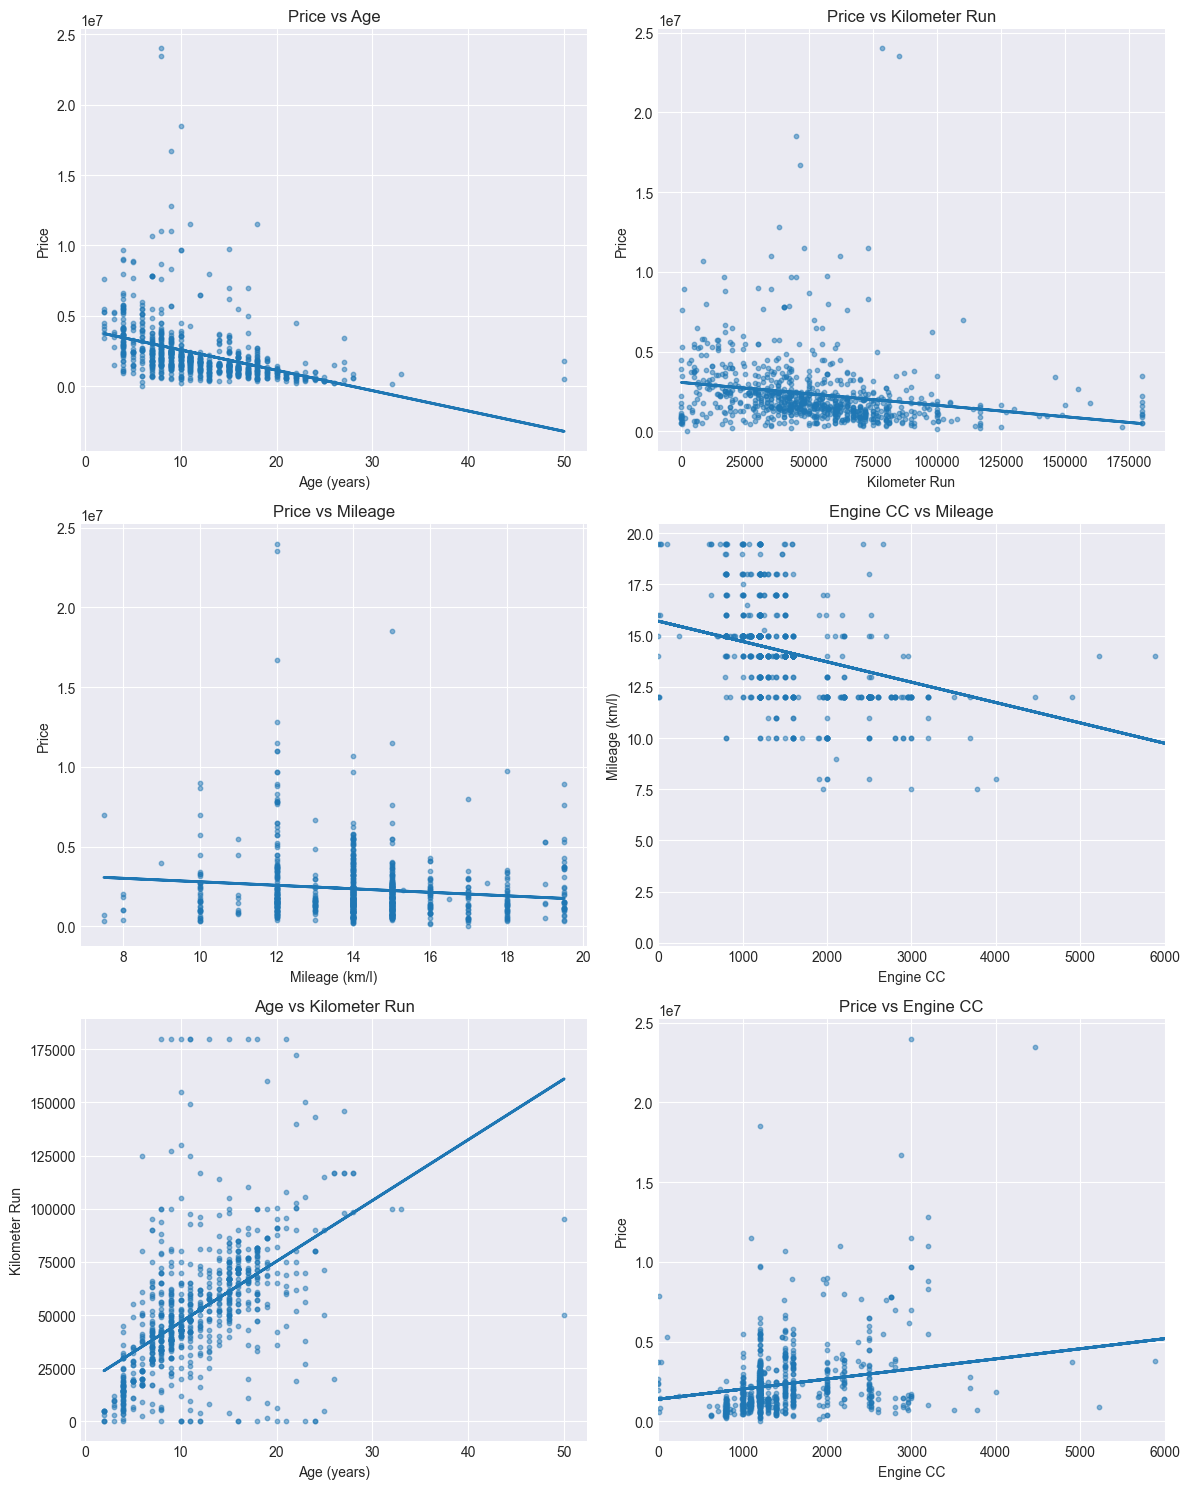

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

def scatter(ax, x, y, x_label, y_label, title):
    # Scatter plot
    ax.scatter(x, y, s=10, alpha=0.5)

    # Trendline
    z = np.polyfit(x, y, 1)  # degree 1 = straight line
    p = np.poly1d(z)
    ax.plot(x, p(x), linewidth=2)

    # Labels and titles
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)

    if(x_label=="Engine CC"):
        ax.set_xlim(0,6000)


# Subplots
scatter(axes[0, 0], df['age'], df['price'], "Age (years)", "Price", "Price vs Age")
scatter(axes[0, 1], df['kilometer_run'], df['price'], "Kilometer Run", "Price", "Price vs Kilometer Run")
scatter(axes[1, 0], df['mileage'], df['price'], "Mileage (km/l)", "Price", "Price vs Mileage")
scatter(axes[1, 1], df['engine_cc'], df['mileage'], "Engine CC", "Mileage (km/l)", "Engine CC vs Mileage")
scatter(axes[2, 0], df['age'], df['kilometer_run'], "Age (years)", "Kilometer Run", "Age vs Kilometer Run")
scatter(axes[2, 1], df['engine_cc'], df['price'], "Engine CC", "Price", "Price vs Engine CC")

# Adjust spacing
plt.tight_layout()
plt.show()

**Insights:**
- Price tends to decrease with increasing age and kilometer run, showing depreciation effects.
- Higher mileage is often associated with lower prices, but some high-mileage cars retain value.
- Engine CC has a positive relationship with price and a varied relationship with mileage.
- Age and kilometer run are positively correlated, as older cars tend to have higher kilometer readings.

**Heatmaps**

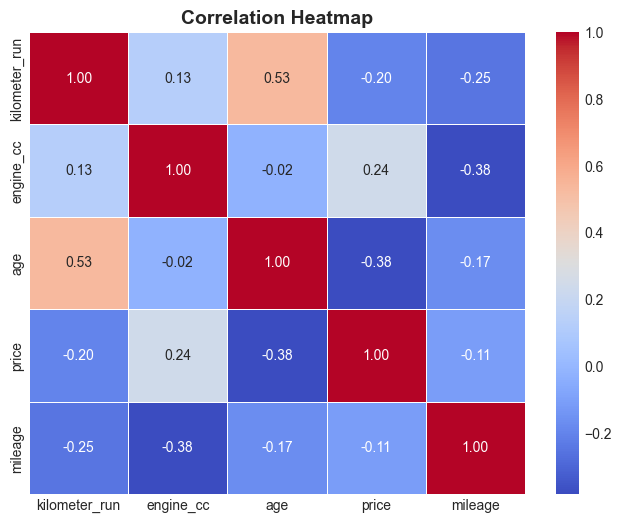

In [8]:
def plot_correlation_heatmap(df, columns, figsize=(8, 6), annot=True, cmap='coolwarm'):
    
    corr_matrix = df[columns].corr()  # Compute correlation matrix
    
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=annot, fmt=".2f", cmap=cmap, linewidths=0.5)
    plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.show()

columns_to_corr = ['kilometer_run','engine_cc','age','price','mileage']
plot_correlation_heatmap(df, columns_to_corr)

**Insights:**
- Price is negatively correlated with age and kilometer run, confirming depreciation trends.
- Mileage shows weak correlation with other features, indicating it is influenced by multiple factors.
- Engine CC and price have a moderate positive correlation, suggesting higher engine capacity cars are more expensive.

<Axes: >

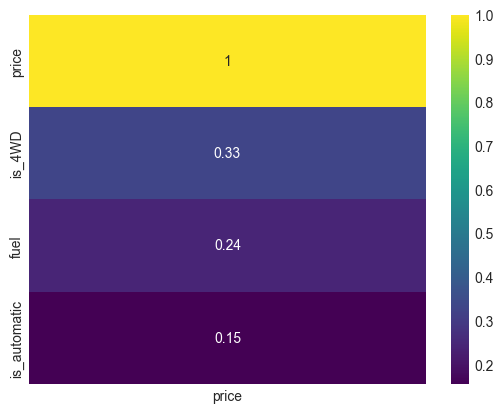

In [9]:

encoded = pd.get_dummies(df[[ 'fuel', 'is_automatic', 'is_4WD']])
corr = encoded.join(df['price']).corr()
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False), annot=True, cmap='viridis')